In [3]:
!pip install supervision

import supervision as sv
import cv2
import requests
import numpy as np

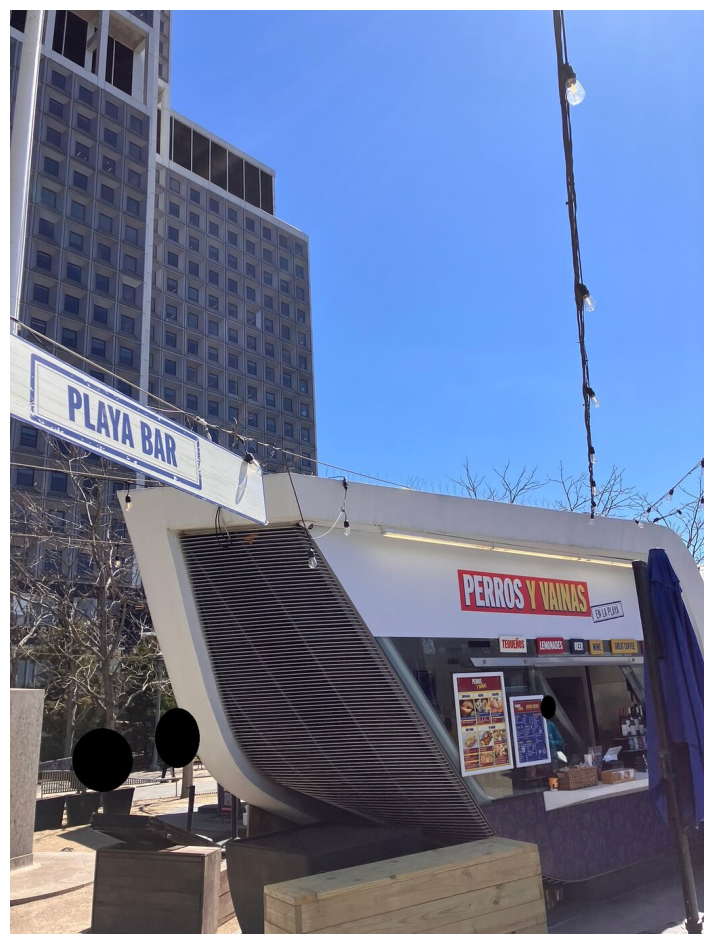

In [5]:
image_url = "https://media-cdn.tripadvisor.com/media/photo-w/33/74/cb/23/caption.jpg"

# Download the image
response = requests.get(image_url)
response.raise_for_status() # Raise an exception for bad status codes

# Read the image from bytes using cv2.imdecode
image_np = np.frombuffer(response.content, np.uint8)
image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

# Check if image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_url}")
else:
    sv.plot_image(image)

In [6]:
import io
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
import requests

# 1. Image Data Payload containing 1280-width image URLs from your list
image_urls = [
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/16/a9/31/22/photo0jpg.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/23/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/18/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/1a/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/1c/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/16/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/1f/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/21/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/17/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/1d/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/20/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/19/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/1e/caption.jpg",
    "https://media-cdn.tripadvisor.com/media/photo-m/1280/33/74/cb/22/caption.jpg",
]

# Prefetch images into memory using requests and PIL
print("Downloading images... please wait.")
image_list = []
for url in image_urls:
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(io.BytesIO(response.content)).resize((600, 350))
        image_list.append(img)
    except Exception as e:
        print(f"Skipping broken URL: {url} due to {e}")

# Counter tracking index
counter = 0

# 2. Set up the UI Components
image_widget = widgets.Image(format="jpeg", width=600, height=350)

info_label = widgets.HTML(
    value=f"<b style='font-size:20px; font-family:Helvetica;'>Image 1 of {len(image_list)}</b>"
)

button = widgets.Button(
    description="Change",
    layout=widgets.Layout(width="160px", height="40px"),
    style={"button_color": "purple"},
)
button.style.text_color = "white"


# 3. Helper function to pipe a PIL Image into the widget byte structure
def load_widget_image(index):
    img_byte_arr = io.BytesIO()
    image_list[index].save(img_byte_arr, format="JPEG")
    image_widget.value = img_byte_arr.getvalue()


# 4. Change image execution target
def ChangeImage(b):
    global counter
    if counter < len(image_list) - 1:
        counter += 1
    else:
        counter = 0

    load_widget_image(counter)
    info_label.value = f"<b style='font-size:20px; font-family:Helvetica;'>Image {counter + 1} of {len(image_list)}</b>"


# Bind the click callback handler
button.on_click(ChangeImage)

# Initialize preview framework with the first picture
load_widget_image(0)

# 5. Render Container Layout
layout_box = widgets.VBox(
    [image_widget, info_label, button],
    layout=widgets.Layout(align_items="center"),
)
display(layout_box)

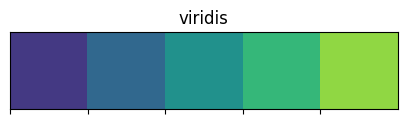

['#443983', '#31688e', '#21918c', '#35b779', '#90d743']


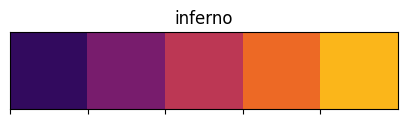

['#320a5e', '#781c6d', '#bc3754', '#ed6925', '#fbb61a']


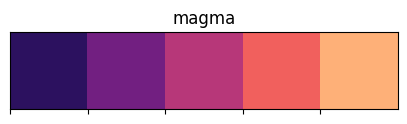

['#2c115f', '#721f81', '#b73779', '#f1605d', '#feb078']


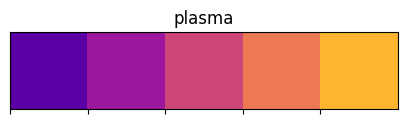

['#5c01a6', '#9c179e', '#cc4778', '#ed7953', '#fdb42f']


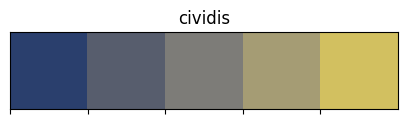

['#2a3f6d', '#575d6d', '#7d7c78', '#a59c74', '#d2c060']


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

viridis = sns.color_palette("viridis", 5).as_hex()
inferno = sns.color_palette("inferno", 5).as_hex()
magma = sns.color_palette("magma", 5).as_hex()
plasma = sns.color_palette("plasma", 5).as_hex()
cividis = sns.color_palette("cividis", 5).as_hex()

# viridis
sns.palplot(viridis)
plt.title("viridis")
plt.show()
print(viridis)

# inferno
sns.palplot(inferno)
plt.title("inferno")
plt.show()
print(inferno)

# magma
sns.palplot(magma)
plt.title("magma")
plt.show()
print(magma)

# plasma
sns.palplot(plasma)
plt.title("plasma")
plt.show()
print(plasma)

# cividis
sns.palplot(cividis)
plt.title("cividis")
plt.show()
print(cividis)